## Overview

This analysis identifies the most optimal skills for Data Analysts by intersecting market demand (count of job postings) with earning potential (average annual salary).

**Methodology**
The visualization utilizes a scatter plot approach to categorize skills into four quadrants based on their prevalence in job listings and their financial compensation. This ensures a balanced view of "safe" skills versus "high-reward" specializations.

**Process Summary**
[x] Filter SQL results to include both demand_count and avg_salary for a comprehensive 2D analysis.

[x] Identify "Core Skills" (High Demand) like Python and R which serve as the foundation for most roles.

[x] Isolate "Optimal Skills" (High Demand & High Salary) such as Snowflake, Azure, and Looker.

[x] Map "Niche High-Pay" skills like Go and Confluence which offer top-tier salaries despite lower volume.


This breakdown provides a clear strategic roadmap: while Python is essential for market entry, adding cloud-specific expertise like Snowflake or Azure creates the most optimal path toward high-paying, stable career opportunities.

**Query 4:**
```sql
SELECT 
    skills_dim.skill_id,
    skills_dim.skills,
    COUNT(skills_job_dim.job_id) AS demand_count,
    ROUND(AVG(job_postings_fact.salary_year_avg), 0) AS avg_salary
FROM job_postings_fact
INNER JOIN skills_job_dim ON job_postings_fact.job_id = skills_job_dim.job_id
INNER JOIN skills_dim ON skills_job_dim.skill_id = skills_dim.skill_id
WHERE
    job_title_short = 'Data Analyst'
    AND salary_year_avg IS NOT NULL
    AND job_work_from_home = True 
GROUP BY
    skills_dim.skill_id
HAVING
    COUNT(skills_job_dim.job_id) > 10
    --- i want only skills that repeat more than 10 times
ORDER BY
    avg_salary DESC,
    demand_count DESC
LIMIT 25;
```

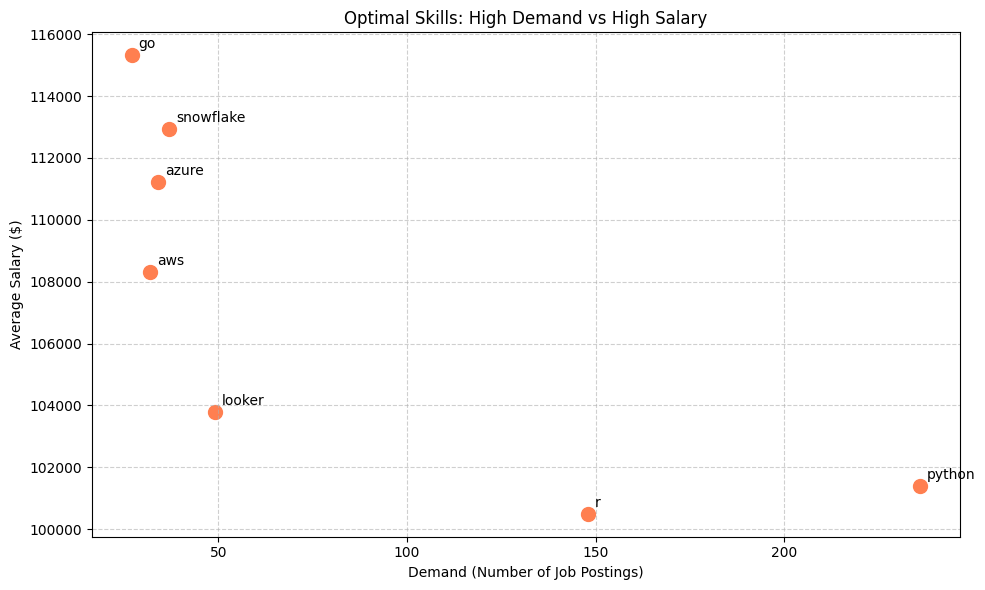

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


data = [
    {"skills": "go", "demand_count": 27, "avg_salary": 115320},
    {"skills": "snowflake", "demand_count": 37, "avg_salary": 112948},
    {"skills": "azure", "demand_count": 34, "avg_salary": 111225},
    {"skills": "aws", "demand_count": 32, "avg_salary": 108317},
    {"skills": "looker", "demand_count": 49, "avg_salary": 103795},
    {"skills": "python", "demand_count": 236, "avg_salary": 101397},
    {"skills": "r", "demand_count": 148, "avg_salary": 100499}
]

df = pd.DataFrame(data)


plt.figure(figsize=(10, 6))
plt.scatter(df['demand_count'], df['avg_salary'], color='coral', s=100)

for i, txt in enumerate(df['skills']):
    plt.annotate(txt, (df['demand_count'][i], df['avg_salary'][i]), xytext=(5,5), textcoords='offset points')


plt.title('Optimal Skills: High Demand vs High Salary')
plt.xlabel('Demand (Number of Job Postings)')
plt.ylabel('Average Salary ($)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()